In [ ]:
# checking how many times a specific Category Alias shows up
AliasCount = YCRDataPrepared.value_counts(subset='Category Alias').reset_index(name='Alias Count')
AliasCount.sort_values(by='Category Alias')

In [ ]:
# checking how many times a specific Category Alias and Category Title combination shows up
AliasTitleMatch = YCRDataPrepared.value_counts(subset=['Category Alias','Category Title']).reset_index(name='Alias Title Match Count')
AliasTitleMatch.sort_values(by='Category Alias')

In [ ]:
# merging the two DataFrames
CombinedCounts = pd.concat([AliasCount, AliasTitleMatch], axis=1, ignore_index=False)
CombinedCounts

In [ ]:
# checking if the counts are the same. if there is a discrepancy, the Alias and Title combinations need to be verified and decided on for clarity
CombinedCounts['Alias Count'].equals(CombinedCounts['Alias Title Match Count'])
# this shows that there is no mismatch of Category Alias and Category Title; we only need to keep one to retain all relevant information.

In [ ]:
# figure out how to 
# find equal values like CleanedCategories.loc[CleanedCategories['Name'].str.lower() == 'Sushibar + Wine'.lower(), 'Name'] = 'Sushibar + Wine'
# how to do the .replace, not working?

In [ ]:
# Sushibar + Wine
# there doesn't seem to be one agreed upon typing. I chose Sushibar + Wine for legibility
YCRDataPrepared.loc[YCRDataPrepared['Name'].str.replace(r'\s+', '', regex=True).str.lower() == 'Sushibar + Wine'.replace(r'\s+', '', regex=True).lower(), 'Name'] = 'Sushibar + Wine'

# viewing results
YCRDataPrepared[YCRDataPrepared['Name'].str.contains('Sushibar')]

In [ ]:
# there doesn't seem to be one agreed upon typing. I chose Sushibar + Wine for legibility
CleanedCategories.loc[CleanedCategories['Name'].str.lower() == 'Sushibar + Wine'.lower(), 'Name'] = 'Sushibar + Wine'
CleanedCategories.loc[CleanedCategories['Name'].str.lower() == 'Sushibar+wine'.lower(), 'Name'] = 'Sushibar + Wine'
CleanedCategories[CleanedCategories['Name'].str.contains('Sushibar')]

In [ ]:
def IdentifyingSameString(DF,DFColumn):
    '''
    Identify all values where the same string has different casing or white space and return them in a DataFrame.

    Args:
        DF (DataFrame): The DataFrame that the data we want to check syntax on is stored in.
        DFColumn (str): The specific column we are checking.
        

    Returns:
        A DataFrame containing all values where the same string has different casing or white space.
    '''

    # getting base duplicates for each string.
    OnlyString = DF[DFColumn]

    # normalizing and getting duplicate counts
    NoWhiteSpaces = OnlyString.str.replace(r'\s+', '', regex=True)
    NormalizedString = NoWhiteSpaces.str.lower()
    
    # base dupicates
    BaseStringDuplicates = DF[DF[DFColumn].duplicated(keep=False) == True]

    # normalized duplicates
    NormalizedDuplicates = DF[DF[DFColumn].str.replace(r'\s+', '', regex=True).str.lower().duplicated(keep=False) == True]

    # shows if a row in a full outer join is from one or both DataFrames
    MergeInfo = BaseStringDuplicates.merge(NormalizedDuplicates, how='outer', indicator=True)

    # show only rows that are present in NormalizedDuplicates
    CasingCleanUp = MergeInfo[MergeInfo['_merge'] != 'both']
    CasingCleanUp
    # seeing what I need to clean up
    LocatedCasingCleanup = DF[DF[DFColumn].str.replace(r'\s+', '', regex=True).str.lower().isin(CasingCleanUp['Name'].str.replace(r'\s+', '', regex=True).str.lower())]
    return LocatedCasingCleanup

In [ ]:
# removing Category Alias column

In [ ]:
# check that the category info is same - if any name + code combo has more than 1

In [ ]:
# continue cleaning process for the one I pick; don't spend time on one I won't pick

---

### How to decide which one to pick:
Compare the quality of the Yelp and Foursquare API. For your location, which API gives you the most complete information/better coverage? NOTE: Your definition of 'coverage' is up to you. It could be simple 'number of POIs in the area', but it could also be something more specific like 'number of reviews per POI', or 'number of different attributes of each POI'.
- look at what info each gives.
- what am I trying to do with the data? 
- which one serves that?

### Scope:
1. Build a regression model using Python’s statsmodels module that demonstrates a relationship between the number of bikes in a particular location and the characteristics of the POIs in that location.
2. Interpret results. Expand on the model output, and derive insights from your model.
3. Stretch: can you think of a way to turn the above regression problem into a classification one? Without coding, can you sketch out how you would cast the problem specifically, and lay out your approaches?

- what characteristics does each give?


In [1]:
import pandas as pd

In [3]:
FS_csv_path = '../data/RevisedCleanedFoursquareData.csv'
FSCRDataPrepared = pd.read_csv(FS_csv_path)
FSCRDataPrepared.head(1)

,Name,Category ID,Category Name,Latitude,Longitude,Distance,Popularity,Price,Rating,Distance_mean,Distance_min,Distance_max,Bike Spots Near,Popularity_mean,Popularity_min,Popularity_max
0,Ravintola Paulette,13148,French Restaurant,60.158526,24.945557,435,0.981589,Affordable,9.1,576.333333,51,966,6,0.981589,0.981589,0.981589


In [4]:
Y_csv_path = '../data/RevisedCleanedYelpData.csv'
YCRDataPrepared = pd.read_csv(Y_csv_path)
YCRDataPrepared.head(1)

,Name,Category Alias,Category Title,Latitude,Longitude,Distance,Price,Rating,Distance_mean,Distance_min,Distance_max,Bike Spots Near
0,Ravintola Vinkkeli,modern_european,Modern European,60.1639,24.94641,993.930059,Most Expensive,5.0,652.820553,104.417207,993.930059,28


- category

---

In [ ]:
# continue the cleaning methods I used originally. case, nulls.

Foursquare

In [2]:
FS_csv_path = '../data/RevisedCleanedFoursquareData.csv'
RevisedCleanedFoursquareData = pd.read_csv(FS_csv_path)
RevisedCleanedFoursquareData

,Name,Category ID,Category Name,Latitude,Longitude,Distance,Popularity,Price,Rating,Distance_mean,Distance_min,Distance_max,Bike Spots Near,Popularity_mean,Popularity_min,Popularity_max
0,Ravintola Paulette,13148,French Restaurant,60.158526,24.945557,435,0.981589,Affordable,9.1,576.333333,51,966,6,0.981589,0.981589,0.981589
1,Kaffa Roastery,13034,Café,60.158463,24.934133,939,0.992039,Affordable,9.0,649.750000,112,939,16,0.992039,0.992039,0.992039
2,Daddy Greens Pizzabar - Iso Roobertinkatu,13064,Pizzeria,60.162840,24.940647,984,0.981128,Most Affordable,8.8,984.000000,984,984,1,0.981128,0.981128,0.981128
3,Ravintola Skiffer,13064,Pizzeria,60.152901,24.946306,354,0.967701,Affordable,8.7,647.333333,354,832,3,0.967701,0.967701,0.967701
4,Ravintola Pastis,13148,French Restaurant,60.164127,24.947772,979,0.982049,Affordable,8.6,643.950000,136,991,20,0.982049,0.982049,0.982049
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24908,Ravintola Töölö,13022,Sports Bar,60.188297,24.917887,580,0.985921,Most Affordable,4.9,538.538462,55,983,13,0.985921,0.985921,0.985921
24909,Hesburger Helsinki Töölö,13145,Fast Food Restaurant,60.184169,24.924048,99,0.979148,Most Affordable,4.9,554.727273,99,981,11,0.979148,0.979148,0.979148
24910,Neste K Eläintarha,13034,Café,60.193018,24.930322,961,0.996032,Not Listed,4.8,715.230769,428,993,13,0.996032,0.996032,0.996032
24911,HSL 1915 Töölön Kisahalli,19043,Bus Stop,60.184650,24.923348,119,0.989687,Not Listed,Not Rated,393.428571,119,698,7,0.989687,0.989687,0.989687


In [5]:
# checking name formatting

# getting base duplicates for each name.
FSOnlyVenueName = RevisedCleanedFoursquareData['Name']
FSOnlyVenueNameDuplicateCounts = FSOnlyVenueName.duplicated(keep=False).value_counts()

# normalizing and getting duplicate counts
FSNormalizedVenueName = FSOnlyVenueName.str.lower()
FSNormalizedVenueNameDuplicateCounts = FSNormalizedVenueName.duplicated(keep=False).value_counts()

# if name duplicate counts are not equal, there is some casing that needs to be corrected
FSOnlyVenueNameDuplicateCounts == FSNormalizedVenueNameDuplicateCounts

Name
True     False
False    False
Name: count, dtype: bool

In [6]:
# base dupicates
FSBaseNameDuplicates = RevisedCleanedFoursquareData[RevisedCleanedFoursquareData['Name'].duplicated(keep=False) == True]
# normalized duplicates
FSNormalizedDuplicates = RevisedCleanedFoursquareData[RevisedCleanedFoursquareData['Name'].str.lower().duplicated(keep=False) == True]

# shows if a row in a full outer join is from one or both DataFrames
FSMergeInfo = FSBaseNameDuplicates.merge(FSNormalizedDuplicates, how='outer', indicator=True)
# show only rows that are present in NormalizedDuplicates
FSCasingCleanUp = FSMergeInfo[FSMergeInfo['_merge'] != 'both']
FSCasingCleanUp

,Name,Category ID,Category Name,Latitude,Longitude,Distance,Popularity,Price,Rating,Distance_mean,Distance_min,Distance_max,Bike Spots Near,Popularity_mean,Popularity_min,Popularity_max,_merge
2552,Eat Poke HKI,13193,Poke Restaurant,60.169558,24.944774,764,0.985517,Not Listed,8.1,764.0,764,764,1,0.985517,0.985517,0.985517,right_only
23450,UniCafe Physicum,10000,Arts and Entertainment,60.204965,24.962550,821,0.934558,Not Listed,Not Rated,821.0,821,821,1,0.934558,0.934558,0.934558,right_only
23471,Unicafe Physicum,10000,Arts and Entertainment,60.204965,24.962550,821,0.985185,Not Listed,Not Rated,821.0,821,821,1,0.985185,0.985185,0.985185,right_only


In [7]:
# seeing what I need to clean up
FSLocatedCasingCleanup = RevisedCleanedFoursquareData[RevisedCleanedFoursquareData['Name'].str.lower().isin(FSCasingCleanUp['Name'].str.lower())]
FSLocatedCasingCleanup


,Name,Category ID,Category Name,Latitude,Longitude,Distance,Popularity,Price,Rating,Distance_mean,Distance_min,Distance_max,Bike Spots Near,Popularity_mean,Popularity_min,Popularity_max
461,Eat Poke HKI,13193,Poke Restaurant,60.169558,24.944774,764,0.985517,Not Listed,8.1,764.000000,764,764,1,0.985517,0.985517,0.985517
7894,Eat Poke Hki,13193,Poke Restaurant,60.184648,24.825432,790,0.508242,Not Listed,Not Rated,565.916667,99,857,12,0.508242,0.508242,0.508242
8088,Eat Poke Hki,13193,Poke Restaurant,60.184648,24.825432,857,0.508242,Not Listed,Not Rated,565.916667,99,857,12,0.508242,0.508242,0.508242
8132,Eat Poke Hki,13193,Poke Restaurant,60.184648,24.825432,640,0.508242,Not Listed,Not Rated,565.916667,99,857,12,0.508242,0.508242,0.508242
8188,Eat Poke Hki,13193,Poke Restaurant,60.184648,24.825432,433,0.508242,Not Listed,Not Rated,565.916667,99,857,12,0.508242,0.508242,0.508242
8240,Eat Poke Hki,13193,Poke Restaurant,60.184648,24.825432,603,0.508242,Not Listed,Not Rated,565.916667,99,857,12,0.508242,0.508242,0.508242
8278,Eat Poke Hki,13193,Poke Restaurant,60.184648,24.825432,441,0.508242,Not Listed,Not Rated,565.916667,99,857,12,0.508242,0.508242,0.508242
8326,Eat Poke Hki,13193,Poke Restaurant,60.184648,24.825432,277,0.508242,Not Listed,Not Rated,565.916667,99,857,12,0.508242,0.508242,0.508242
8370,Eat Poke Hki,13193,Poke Restaurant,60.184648,24.825432,99,0.508242,Not Listed,Not Rated,565.916667,99,857,12,0.508242,0.508242,0.508242
8489,Eat Poke Hki,13193,Poke Restaurant,60.184648,24.825432,663,0.508242,Not Listed,Not Rated,565.916667,99,857,12,0.508242,0.508242,0.508242


In [10]:
# Naughty BRGR is correct
RevisedCleanedFoursquareData.loc[RevisedCleanedFoursquareData['Name'].str.lower() == 'Naughty BRGR'.lower(), 'Name'] = 'Naughty BRGR'

# Eat Poke HKI is correct
RevisedCleanedFoursquareData.loc[RevisedCleanedFoursquareData['Name'].str.lower() == 'Eat Poke HKI'.lower(), 'Name'] = 'Eat Poke HKI'

# Fafa's is correct
RevisedCleanedFoursquareData.loc[RevisedCleanedFoursquareData['Name'].str.lower() == 'Fafa’s'.lower(), 'Name'] = 'Fafa’s'

# UniCafe Physicum is correct
RevisedCleanedFoursquareData.loc[RevisedCleanedFoursquareData['Name'].str.lower() == 'UniCafe Physicum'.lower(), 'Name'] = 'UniCafe Physicum'

In [11]:
RevisedCleanedFoursquareData[RevisedCleanedFoursquareData['Name'].str.lower().isin(FSCasingCleanUp['Name'].str.lower())]

,Name,Category ID,Category Name,Latitude,Longitude,Distance,Popularity,Price,Rating,Distance_mean,Distance_min,Distance_max,Bike Spots Near,Popularity_mean,Popularity_min,Popularity_max
461,Eat Poke HKI,13193,Poke Restaurant,60.169558,24.944774,764,0.985517,Not Listed,8.1,764.000000,764,764,1,0.985517,0.985517,0.985517
7894,Eat Poke HKI,13193,Poke Restaurant,60.184648,24.825432,790,0.508242,Not Listed,Not Rated,565.916667,99,857,12,0.508242,0.508242,0.508242
8088,Eat Poke HKI,13193,Poke Restaurant,60.184648,24.825432,857,0.508242,Not Listed,Not Rated,565.916667,99,857,12,0.508242,0.508242,0.508242
8132,Eat Poke HKI,13193,Poke Restaurant,60.184648,24.825432,640,0.508242,Not Listed,Not Rated,565.916667,99,857,12,0.508242,0.508242,0.508242
8188,Eat Poke HKI,13193,Poke Restaurant,60.184648,24.825432,433,0.508242,Not Listed,Not Rated,565.916667,99,857,12,0.508242,0.508242,0.508242
8240,Eat Poke HKI,13193,Poke Restaurant,60.184648,24.825432,603,0.508242,Not Listed,Not Rated,565.916667,99,857,12,0.508242,0.508242,0.508242
8278,Eat Poke HKI,13193,Poke Restaurant,60.184648,24.825432,441,0.508242,Not Listed,Not Rated,565.916667,99,857,12,0.508242,0.508242,0.508242
8326,Eat Poke HKI,13193,Poke Restaurant,60.184648,24.825432,277,0.508242,Not Listed,Not Rated,565.916667,99,857,12,0.508242,0.508242,0.508242
8370,Eat Poke HKI,13193,Poke Restaurant,60.184648,24.825432,99,0.508242,Not Listed,Not Rated,565.916667,99,857,12,0.508242,0.508242,0.508242
8489,Eat Poke HKI,13193,Poke Restaurant,60.184648,24.825432,663,0.508242,Not Listed,Not Rated,565.916667,99,857,12,0.508242,0.508242,0.508242


Yelp

In [ ]:
Y_csv_path = '../data/RevisedCleanedYelpData.csv'
RevisedCleanedYelpData = pd.read_csv(Y_csv_path)
RevisedCleanedYelpData

,Name,Category ID,Category Name,Latitude,Longitude,Distance,Popularity,Price,Rating,Distance_mean,Distance_min,Distance_max,Bike Spots Near,Popularity_mean,Popularity_min,Popularity_max
0,Ravintola Paulette,13148,French Restaurant,60.158526,24.945557,435,0.981589,Affordable,9.1,576.333333,51,966,6,0.981589,0.981589,0.981589
1,Kaffa Roastery,13034,Café,60.158463,24.934133,939,0.992039,Affordable,9.0,649.750000,112,939,16,0.992039,0.992039,0.992039
2,Daddy Greens Pizzabar - Iso Roobertinkatu,13064,Pizzeria,60.162840,24.940647,984,0.981128,Most Affordable,8.8,984.000000,984,984,1,0.981128,0.981128,0.981128
3,Ravintola Skiffer,13064,Pizzeria,60.152901,24.946306,354,0.967701,Affordable,8.7,647.333333,354,832,3,0.967701,0.967701,0.967701
4,Ravintola Pastis,13148,French Restaurant,60.164127,24.947772,979,0.982049,Affordable,8.6,643.950000,136,991,20,0.982049,0.982049,0.982049
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24908,Ravintola Töölö,13022,Sports Bar,60.188297,24.917887,580,0.985921,Most Affordable,4.9,538.538462,55,983,13,0.985921,0.985921,0.985921
24909,Hesburger Helsinki Töölö,13145,Fast Food Restaurant,60.184169,24.924048,99,0.979148,Most Affordable,4.9,554.727273,99,981,11,0.979148,0.979148,0.979148
24910,Neste K Eläintarha,13034,Café,60.193018,24.930322,961,0.996032,Not Listed,4.8,715.230769,428,993,13,0.996032,0.996032,0.996032
24911,HSL 1915 Töölön Kisahalli,19043,Bus Stop,60.184650,24.923348,119,0.989687,Not Listed,Not Rated,393.428571,119,698,7,0.989687,0.989687,0.989687


In [ ]:
# checking name formatting

# getting base duplicates for each name.
YOnlyVenueName = RevisedCleanedYelpData['Name']
YOnlyVenueNameDuplicateCounts = YOnlyVenueName.duplicated(keep=False).value_counts()

# normalizing and getting duplicate counts
YNormalizedVenueName = YOnlyVenueName.str.lower()
YNormalizedVenueNameDuplicateCounts = YNormalizedVenueName.duplicated(keep=False).value_counts()

# if name duplicate counts are not equal, there is some casing that needs to be corrected
YOnlyVenueNameDuplicateCounts == YNormalizedVenueNameDuplicateCounts

Name
True     False
False    False
Name: count, dtype: bool

In [ ]:
# base dupicates
YBaseNameDuplicates = RevisedCleanedYelpData[RevisedCleanedYelpData['Name'].duplicated(keep=False) == True]
# normalized duplicates
YNormalizedDuplicates = RevisedCleanedYelpData[RevisedCleanedYelpData['Name'].str.lower().duplicated(keep=False) == True]

# shows if a row in a full outer join is from one or both DataFrames
YMergeInfo = YBaseNameDuplicates.merge(YNormalizedDuplicates, how='outer', indicator=True)
# show only rows that are present in NormalizedDuplicates
YCasingCleanUp = YMergeInfo[YMergeInfo['_merge'] != 'both']
YCasingCleanUp

,Name,Category ID,Category Name,Latitude,Longitude,Distance,Popularity,Price,Rating,Distance_mean,Distance_min,Distance_max,Bike Spots Near,Popularity_mean,Popularity_min,Popularity_max,_merge
2552,Eat Poke HKI,13193,Poke Restaurant,60.169558,24.944774,764,0.985517,Not Listed,8.1,764.0,764,764,1,0.985517,0.985517,0.985517,right_only
23450,UniCafe Physicum,10000,Arts and Entertainment,60.204965,24.962550,821,0.934558,Not Listed,Not Rated,821.0,821,821,1,0.934558,0.934558,0.934558,right_only
23471,Unicafe Physicum,10000,Arts and Entertainment,60.204965,24.962550,821,0.985185,Not Listed,Not Rated,821.0,821,821,1,0.985185,0.985185,0.985185,right_only


In [ ]:
# seeing what I need to clean up
YLocatedCasingCleanup = RevisedCleanedYelpData[RevisedCleanedYelpData['Name'].str.lower().isin(YCasingCleanUp['Name'].str.lower())]
YLocatedCasingCleanup


,Name,Category ID,Category Name,Latitude,Longitude,Distance,Popularity,Price,Rating,Distance_mean,Distance_min,Distance_max,Bike Spots Near,Popularity_mean,Popularity_min,Popularity_max
461,Eat Poke HKI,13193,Poke Restaurant,60.169558,24.944774,764,0.985517,Not Listed,8.1,764.000000,764,764,1,0.985517,0.985517,0.985517
7894,Eat Poke Hki,13193,Poke Restaurant,60.184648,24.825432,790,0.508242,Not Listed,Not Rated,565.916667,99,857,12,0.508242,0.508242,0.508242
8088,Eat Poke Hki,13193,Poke Restaurant,60.184648,24.825432,857,0.508242,Not Listed,Not Rated,565.916667,99,857,12,0.508242,0.508242,0.508242
8132,Eat Poke Hki,13193,Poke Restaurant,60.184648,24.825432,640,0.508242,Not Listed,Not Rated,565.916667,99,857,12,0.508242,0.508242,0.508242
8188,Eat Poke Hki,13193,Poke Restaurant,60.184648,24.825432,433,0.508242,Not Listed,Not Rated,565.916667,99,857,12,0.508242,0.508242,0.508242
8240,Eat Poke Hki,13193,Poke Restaurant,60.184648,24.825432,603,0.508242,Not Listed,Not Rated,565.916667,99,857,12,0.508242,0.508242,0.508242
8278,Eat Poke Hki,13193,Poke Restaurant,60.184648,24.825432,441,0.508242,Not Listed,Not Rated,565.916667,99,857,12,0.508242,0.508242,0.508242
8326,Eat Poke Hki,13193,Poke Restaurant,60.184648,24.825432,277,0.508242,Not Listed,Not Rated,565.916667,99,857,12,0.508242,0.508242,0.508242
8370,Eat Poke Hki,13193,Poke Restaurant,60.184648,24.825432,99,0.508242,Not Listed,Not Rated,565.916667,99,857,12,0.508242,0.508242,0.508242
8489,Eat Poke Hki,13193,Poke Restaurant,60.184648,24.825432,663,0.508242,Not Listed,Not Rated,565.916667,99,857,12,0.508242,0.508242,0.508242


In [ ]:
# accounting for spacing
RevisedCleanedYelpData[RevisedCleanedYelpData['Name'].str.contains('Sushibar')]

,Name,Category Alias,Category Title,Latitude,Longitude,Price,Rating
1036,Sushibar+Wine,sushi,Sushi Bars,60.164719,24.940470,Affordable,4.2
1265,Sushibar + Wine,sushi,Sushi Bars,60.184078,24.919795,Not Listed,4.3
1307,Sushibar + Wine,sushi,Sushi Bars,60.184078,24.919795,Not Listed,4.3
1335,Sushibar+wine,sushi,Sushi Bars,60.170216,24.941451,Not Listed,5.0
1951,Sushibar + Wine,sushi,Sushi Bars,60.166870,24.932650,Expensive,3.9
2732,Sushibar + Wine,sushi,Sushi Bars,60.184078,24.919795,Not Listed,4.3
2779,Sushibar + Wine,sushi,Sushi Bars,60.184078,24.919795,Not Listed,4.3
2828,Sushibar + Wine,sushi,Sushi Bars,60.184078,24.919795,Not Listed,4.3
2874,Sushibar + Wine,sushi,Sushi Bars,60.184078,24.919795,Not Listed,4.3
2923,Sushibar + Wine,sushi,Sushi Bars,60.184078,24.919795,Not Listed,4.3


In [ ]:
# there doesn't seem to be one agreed upon typing. I chose Sushibar + Wine for legibility
RevisedCleanedYelpData.loc[RevisedCleanedYelpData['Name'].str.lower() == 'Sushibar + Wine'.lower(), 'Name'] = 'Sushibar + Wine'
RevisedCleanedYelpData.loc[RevisedCleanedYelpData['Name'].str.lower() == 'Sushibar+wine'.lower(), 'Name'] = 'Sushibar + Wine'
RevisedCleanedYelpData[RevisedCleanedYelpData['Name'].str.contains('Sushibar')]

,Name,Category Alias,Category Title,Latitude,Longitude,Price,Rating
1036,Sushibar + Wine,sushi,Sushi Bars,60.164719,24.940470,Affordable,4.2
1265,Sushibar + Wine,sushi,Sushi Bars,60.184078,24.919795,Not Listed,4.3
1307,Sushibar + Wine,sushi,Sushi Bars,60.184078,24.919795,Not Listed,4.3
1335,Sushibar + Wine,sushi,Sushi Bars,60.170216,24.941451,Not Listed,5.0
1951,Sushibar + Wine,sushi,Sushi Bars,60.166870,24.932650,Expensive,3.9
2732,Sushibar + Wine,sushi,Sushi Bars,60.184078,24.919795,Not Listed,4.3
2779,Sushibar + Wine,sushi,Sushi Bars,60.184078,24.919795,Not Listed,4.3
2828,Sushibar + Wine,sushi,Sushi Bars,60.184078,24.919795,Not Listed,4.3
2874,Sushibar + Wine,sushi,Sushi Bars,60.184078,24.919795,Not Listed,4.3
2923,Sushibar + Wine,sushi,Sushi Bars,60.184078,24.919795,Not Listed,4.3


---

In [ ]:
# making a function for showing results of same name different case
# using already coded

In [ ]:
# also add in removing white space to this check - can check for same name that has more or less spaces

---

In [ ]:
# doing same for the category

In [8]:
# checking name formatting

# getting base dulpicate counts
OnlyVenueName = CleanedCategories['Name']
OnlyVenueNameDuplicateCounts = OnlyVenueName.duplicated(keep=False).value_counts()
# normalizing and getting duplicate counts
NormalizedVenueName = OnlyVenueName.str.lower()
NormalizedVenueNameDuplicateCounts = NormalizedVenueName.duplicated(keep=False).value_counts()

# if name duplicate counts are not equal, there is some mistyping that needs to be corrected
OnlyVenueNameDuplicateCounts == NormalizedVenueNameDuplicateCounts

NameError: name 'CleanedCategories' is not defined

In [ ]:
# base dupicates
BaseNameDuplicates = CleanedCategories[CleanedCategories['Name'].duplicated(keep=False) == True]
# normalized duplicates
NormalizedDuplicates = CleanedCategories[CleanedCategories['Name'].str.lower().duplicated(keep=False) == True]

# shows if a row in a full outer join is from one or both DataFrames
MergeInfo = BaseNameDuplicates.merge(NormalizedDuplicates, how='outer', indicator=True)
# show only rows that are present in NormalizedDuplicates
CasingCleanUp = MergeInfo[MergeInfo['_merge'] != 'both']
CasingCleanUp


In [ ]:
# seeing what I need to clean up
LocatedCasingCleanup = CleanedCategories[CleanedCategories['Name'].str.lower().isin(CasingCleanUp['Name'].str.lower())]
LocatedCasingCleanup

In [ ]:
# accounting for spacing
CleanedCategories[CleanedCategories['Name'].str.contains('Sushibar')]

---

# comparing the data. choosing 1
look at my feedback and just decide my direction also

In [46]:
FS_csv_path = '../data/RevisedCleanedFoursquareData.csv'
FSCRDataFinal = pd.read_csv(FS_csv_path)

In [50]:
YCRDataFinal

,Name,Category Alias,Category Title,Latitude,Longitude,Distance,Price,Rating,Distance_mean,Distance_min,Distance_max,Bike Spots Near
0,Ravintola Vinkkeli,modern_european,Modern European,60.163900,24.946410,993.930059,Most Expensive,5.0,652.820553,104.417207,993.930059,28
1,Baskeri & Basso,bistros,Bistros,60.157873,24.934694,906.269559,Affordable,4.8,673.116165,83.377593,978.824142,16
2,Chef & Sommelier,scandinavian,Scandinavian,60.157660,24.942540,489.112498,Most Expensive,4.8,641.800023,134.034975,943.511457,14
3,Spis,scandinavian,Scandinavian,60.163631,24.947679,910.667273,Most Expensive,4.8,636.883659,122.448928,951.268827,24
4,Ani,turkish,Turkish,60.157150,24.933661,941.072231,Affordable,4.5,718.839949,163.361331,995.254401,16
...,...,...,...,...,...,...,...,...,...,...,...,...
9730,Karhu Ministeri,pubs,Pubs,60.189571,24.917259,705.595387,Affordable,3.3,511.016285,192.545596,902.743177,11
9731,Ravintola Lehtovaara,scandinavian,Scandinavian,60.183600,24.915930,542.047402,Most Expensive,3.3,592.193958,190.699671,961.362096,9
9732,Boatip,thai,Thai,60.184929,24.941851,891.112679,Most Affordable,4.0,858.743008,826.373336,891.112679,2
9733,Diyalo,himalayan,Himalayan/Nepalese,60.184676,24.923223,125.893234,Affordable,4.0,527.561874,125.893234,909.115155,7


In [51]:
FSCRDataFinal

,Name,Category ID,Category Name,Latitude,Longitude,Distance,Popularity,Price,Rating,Distance_mean,Distance_min,Distance_max,Bike Spots Near,Popularity_mean,Popularity_min,Popularity_max
0,Ravintola Paulette,13148,French Restaurant,60.158526,24.945557,435,0.981589,Affordable,9.1,576.333333,51,966,6,0.981589,0.981589,0.981589
1,Kaffa Roastery,13034,Café,60.158463,24.934133,939,0.992039,Affordable,9.0,649.750000,112,939,16,0.992039,0.992039,0.992039
2,Daddy Greens Pizzabar - Iso Roobertinkatu,13064,Pizzeria,60.162840,24.940647,984,0.981128,Most Affordable,8.8,984.000000,984,984,1,0.981128,0.981128,0.981128
3,Ravintola Skiffer,13064,Pizzeria,60.152901,24.946306,354,0.967701,Affordable,8.7,647.333333,354,832,3,0.967701,0.967701,0.967701
4,Ravintola Pastis,13148,French Restaurant,60.164127,24.947772,979,0.982049,Affordable,8.6,643.950000,136,991,20,0.982049,0.982049,0.982049
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24908,Ravintola Töölö,13022,Sports Bar,60.188297,24.917887,580,0.985921,Most Affordable,4.9,538.538462,55,983,13,0.985921,0.985921,0.985921
24909,Hesburger Helsinki Töölö,13145,Fast Food Restaurant,60.184169,24.924048,99,0.979148,Most Affordable,4.9,554.727273,99,981,11,0.979148,0.979148,0.979148
24910,Neste K Eläintarha,13034,Café,60.193018,24.930322,961,0.996032,Not Listed,4.8,715.230769,428,993,13,0.996032,0.996032,0.996032
24911,HSL 1915 Töölön Kisahalli,19043,Bus Stop,60.184650,24.923348,119,0.989687,Not Listed,Not Rated,393.428571,119,698,7,0.989687,0.989687,0.989687


9735 data points from Yelp vs 24913 data points from Foursquare.

In [ ]:
# comparing null values


In [54]:
YCRDataFinal.isnull().value_counts()

Name   Category Alias  Category Title  Latitude  Longitude  Distance  Price  Rating  Distance_mean  Distance_min  Distance_max  Bike Spots Near
False  False           False           False     False      False     False  False   False          False         False         False              5407
                                                                      True   False   False          False         False         False              4321
       True            True            False     False      False     True   False   False          False         False         False                 7
Name: count, dtype: int64

In [55]:
FSCRDataFinal.isnull().value_counts()

Name   Category ID  Category Name  Latitude  Longitude  Distance  Popularity  Price  Rating  Distance_mean  Distance_min  Distance_max  Bike Spots Near  Popularity_mean  Popularity_min  Popularity_max
False  False        False          False     False      False     False       False  False   False          False         False         False            False            False           False             24007
                                                                  True        False  False   False          False         False         False            True             True            True                902
                                                                                                                                                         False            False           False                 4
Name: count, dtype: int64

Foursquare has less nulls to contend with

---

# analyzing these graphs.

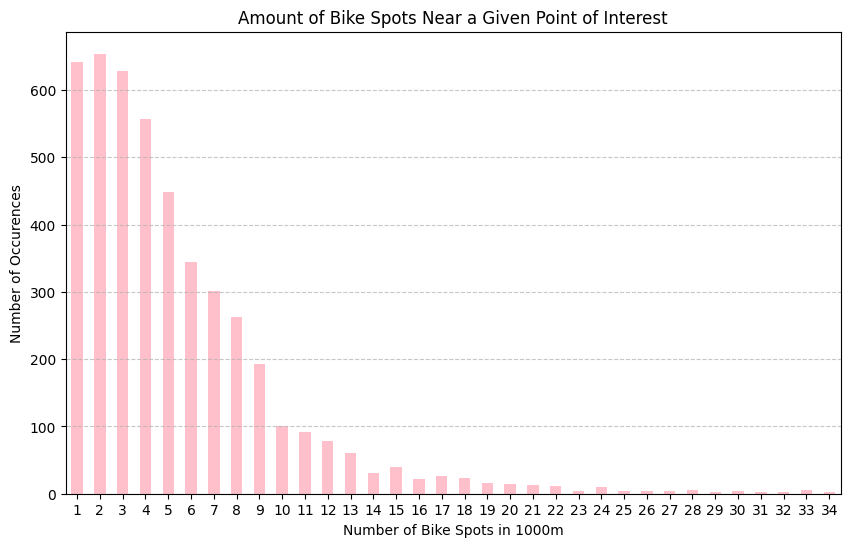

In [ ]:
# plotting the frequency of Bike Spots near Points of Interest
plt.figure(figsize=(10, 6))
FSCRDataFrequency.plot(kind='bar', color='pink')
plt.title('Amount of Bike Spots Near a Given Point of Interest')
plt.xlabel('Number of Bike Spots in 1000m')
plt.ylabel('Number of Occurences')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

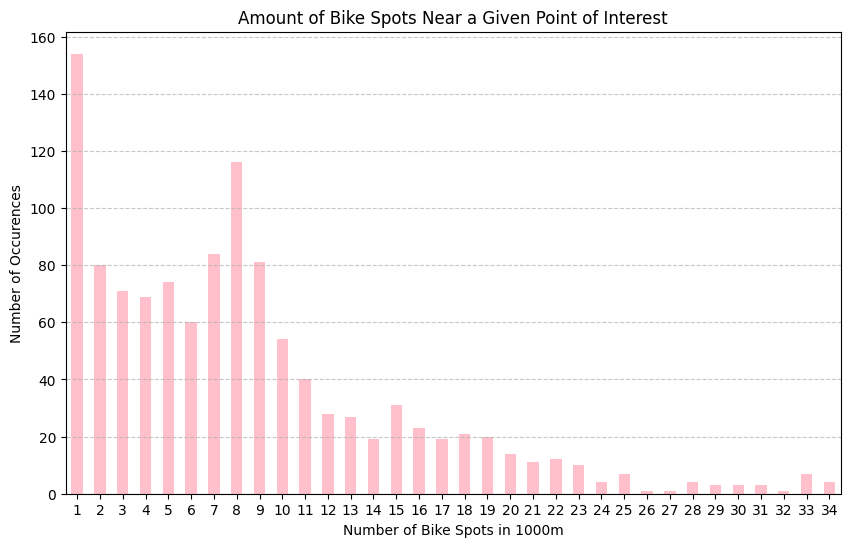

In [ ]:
# plotting the frequency of Bike Spots near Points of Interest
plt.figure(figsize=(10, 6))
YCRDataFrequency.plot(kind='bar', color='pink')
plt.title('Amount of Bike Spots Near a Given Point of Interest')
plt.xlabel('Number of Bike Spots in 1000m')
plt.ylabel('Number of Occurences')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

---

In [ ]:
# dealing with potential duplicates of category. i just got way tired

---

In [ ]:
25019 
25231 

In [ ]:
# combining the data from the API call with the calculated distance data for each Point of Interest
FSCRDistancesAdded = pd.merge(
    left=FSCRDataWithinRadius, 
    right=FSCRDataDistances,
    how='left',
    left_on=['Name', 'Latitude', 'Longitude'],
    right_on=['Name', 'Latitude', 'Longitude'],
)
FSCRDistancesAdded

In [ ]:
# combining the combined data above with the calculated counts of Bike Spots near each Point of Interest
FSCRDistancesStats = pd.merge(
    left=FSCRDistancesAdded, 
    right=FSCRDataGroupedPOI,
    how='left',
    left_on=['Name', 'Latitude', 'Longitude'],
    right_on=['Name', 'Latitude', 'Longitude'],
)
FSCRDistancesStats

In [ ]:
25019 
235159 

In [ ]:
# I saw a specific location so I want to see if the end result is giving me more duplicates


In [ ]:
# check the differing values and that things are working properly
    # I want to make sure the values are all proper, or I can remove and work with only the min max mean

---

### changing the naming of DataFrames make when joining to increase clarity
(ctrl+f the cell below in the project notebook and replace the cells below)

---

In [ ]:
# joining in the Popularity values like with Distance

---

In [ ]:
# doing the same thing for Yelp Data

---

In [ ]:
# removing values that are a further distance than the expected radius of 1000m
YCRDataWithinRadius = pd.DataFrame(YCRData[YCRData['Distance'] <= 1000])
YCRDataWithinRadius

In [ ]:
# getting the count of unique distances per Point of Interest. the distance is from a Bike Spot; unique values are unique Bike Spots
YCRDataGroupedPOI = YCRDataWithinRadius.groupby(['Name','Latitude','Longitude'])['Distance'].nunique()
YCRDataGroupedPOI

In [ ]:
# resetting index to convert the groupby object into a DataFrame
YCRDataGroupedPOI = YCRDataGroupedPOI.reset_index(name='Bike Spots Near')
YCRDataGroupedPOI

In [ ]:
# counting occurences of locations
YCRDataFrequency = YCRDataGroupedPOI['Bike Spots Near'].value_counts().sort_index()
YCRDataFrequency

In [ ]:
# plotting the frequency of Bike Spots near Points of Interest
plt.figure(figsize=(10, 6))
YCRDataFrequency.plot(kind='bar', color='pink')
plt.title('Amount of Bike Spots Near a Given Point of Interest')
plt.xlabel('Number of Bike Spots in 1000m')
plt.ylabel('Number of Occurences')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

ANALYSIS

In [ ]:
# checking if duplicate POIs have different values
YCRDataWithinRadius.duplicated(subset=['Name','Latitude','Longitude']).value_counts() == YCRDataWithinRadius.duplicated(subset=['Name','Latitude','Longitude','Popularity']).value_counts()

In [ ]:
# identifying POI with duplicates
POIDuplicates = YCRDataWithinRadius[YCRDataWithinRadius.duplicated(subset=['Name','Latitude','Longitude'], keep=False)]
POIDuplicates

---

In [ ]:
# keeping the data points because they're all unique and have data
# just adding the stat column for distance

---

In [ ]:
# do the process from my project, just with this 'duplicate removed' data instead

In [ ]:
# finding duplicated POI by using the counter


In [ ]:

# seeing if any duplicates have different descriptions
FSCRDataDuplicatesDescr 
FSCRDataWithinRadius 

In [ ]:
FSCRDataDuplicates = FSCRData.duplicated(subset=['Name','Latitude','Longitude'])

# seeing if any duplicates have different descriptions
FSCRDataDuplicatesDescr = FSCRData.duplicated(subset=['Name','Latitude','Longitude','Description'])

FSCRDataDuplicates.value_counts() == FSCRDataDuplicatesDescr.value_counts()

---

In [ ]:
# make a note in my readme of this

In [ ]:
# see max of max
FSCRDataDistances.sort_values(by='Distance_max',ascending=False)

In [ ]:
# group by POI and show the different distances. useful to get more big picture distance info.
    # such as average distance of a POI from a Bike Spot
    # such as average distance of a type of POI (library, restaraunt) from a Bike Spot

In [ ]:
# get average distance from a POI to a bike spot
# get min
# get max